In [12]:
import os
import joblib
import numpy as np
import seaborn as sns
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder, TargetEncoder,
    StandardScaler, RobustScaler,
    FunctionTransformer
)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

file_path = os.path.join(os.path.dirname(os.path.abspath(os.getcwd())), "data", "rent_prediction.csv")

df = pd.read_csv(file_path)

In [13]:
numeric_cols = list(df.drop("IdentifiantMaison", axis=1).select_dtypes(include=["number"]).columns)
category_cols = list(df.drop("IdentifiantMaison", axis=1).select_dtypes(include=["object", "str"]).columns)

### Traitement de valeurs maquantes

Chambres 25
Salon 25
SalleDeBainInterieure 25
Parking 25
Meuble 25
Jardin 25
Superficie_m2 25
DistanceRoute_m 25
Quartier 25
AgeMaison 25


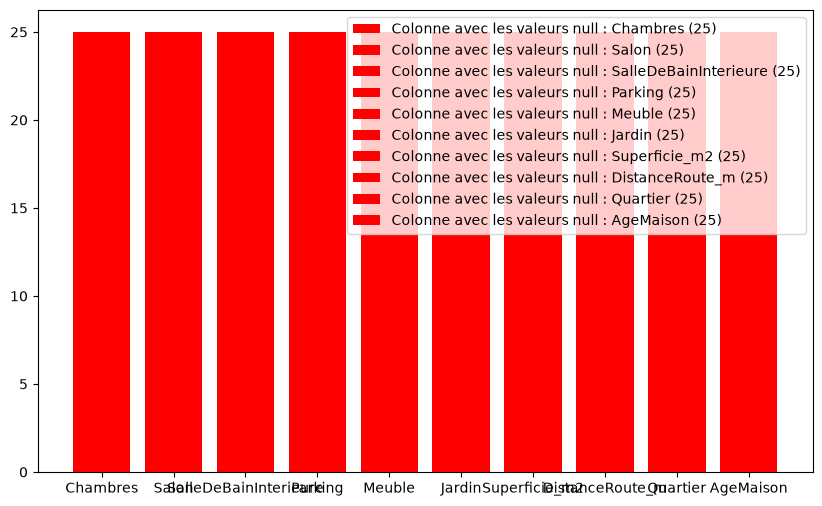

In [14]:
empty_values = df.isnull().sum().sort_values(ascending=False)
cols_with_empty_values = empty_values[empty_values > 0]

plt.figure(figsize=(10, 6))

if len(cols_with_empty_values) > 0:
    for i, _ in enumerate(cols_with_empty_values):
        col_name = cols_with_empty_values.index[i]
        col_value = cols_with_empty_values.values[i]
    
        print(col_name, col_value)
        
        label = f"Colonne avec les valeurs null : {col_name} ({col_value})"
        plt.bar(cols_with_empty_values.index, cols_with_empty_values.values, color="r", label=label)
else:
    label = "Pas de colonnes avec de valeurs nulles"
    plt.bar(cols_with_empty_values.index, cols_with_empty_values.values, color="r", label=label)

plt.legend()
plt.show()

In [15]:
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in ['Salon', 'SalleDeBainInterieure', 'Parking', 'Meuble', 'Jardin', 'Quartier']:
    df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum()

IdentifiantMaison        0
Chambres                 0
Salon                    0
SalleDeBainInterieure    0
Parking                  0
Meuble                   0
Jardin                   0
Superficie_m2            0
DistanceRoute_m          0
Quartier                 0
AgeMaison                0
LoyerMensuel_BIF         0
dtype: int64

### Lignes en double et Catégories incohérentes

In [16]:
# df.duplicated()
df.duplicated().sum()

np.int64(0)

In [17]:
for col in category_cols:
    print(f"{col} --> {df[col].dropna().unique()}")

Salon --> <ArrowStringArray>
['Oui', 'Non']
Length: 2, dtype: str
SalleDeBainInterieure --> <ArrowStringArray>
['Oui', 'Non']
Length: 2, dtype: str
Parking --> <ArrowStringArray>
['Oui', 'Non']
Length: 2, dtype: str
Meuble --> <ArrowStringArray>
['Non', 'Oui']
Length: 2, dtype: str
Jardin --> <ArrowStringArray>
['Oui', 'Non']
Length: 2, dtype: str
Quartier --> <ArrowStringArray>
[    'Rohero',   'Kinanira', 'Gasekebuye',    'Gihosha',    'Kamenge',
       'Jabe',     'Kinama',     'Kiriri',    'Ngagara',    'Buyenzi',
      'Bwiza',   'Cibitoke',  'Nyakabiga',     'Musaga']
Length: 14, dtype: str


### Les valeurs aberrantes

In [18]:
def outlier_values(series, limit_lower_percent=0.25, limit_large_percent=0.75):
    quantile1, quantile3 = series.quantile(limit_lower_percent), series.quantile(limit_large_percent)
    interquantile_range = quantile3 - quantile1
    
    return quantile1 - (interquantile_range * 1.5), quantile3 + (interquantile_range * 1.5)

for col in numeric_cols:
    lower_limit, large_limit = outlier_values(df[col].dropna())

    outliers = df[(df[col] < lower_limit) | (df[col] > large_limit)]
    print()
    print(f"{col}: {len(outliers)} valeurs abberantes potentielles (bornes : {lower_limit:.1f} à {large_limit:.1f}) sur {len(df[col].dropna())}")


Chambres: 0 valeurs abberantes potentielles (bornes : -2.5 à 9.5) sur 510

Superficie_m2: 0 valeurs abberantes potentielles (bornes : -72.5 à 411.5) sur 510

DistanceRoute_m: 0 valeurs abberantes potentielles (bornes : -133.6 à 433.4) sur 510

AgeMaison: 0 valeurs abberantes potentielles (bornes : -17.5 à 58.5) sur 510

LoyerMensuel_BIF: 0 valeurs abberantes potentielles (bornes : -770349.5 à 3150382.5) sur 510


### Séparation de données d'entrainement et de test

In [19]:
# X = df.drop("LoyerMensuel_BIF", axis=1)
# y = df["LoyerMensuel_BIF"]
train_data, test_data = train_test_split(df, test_size=0.25, random_state=45)

path = os.path.join(os.path.dirname(os.path.abspath(os.getcwd())), "data", "test_data.parquet")

train_data.to_parquet(path, index=False)
print("Données sauvegardées avec succèss")

train_data.head()

Données sauvegardées avec succèss


,IdentifiantMaison,Chambres,Salon,SalleDeBainInterieure,Parking,Meuble,Jardin,Superficie_m2,DistanceRoute_m,Quartier,AgeMaison,LoyerMensuel_BIF
191,192,1.0,Oui,Oui,Non,Non,Non,46.0,154.0,Buyenzi,20.0,199931
280,281,4.0,Oui,Oui,Non,Non,Non,217.0,211.0,Kinama,23.0,773800
487,488,4.0,Oui,Oui,Oui,Non,Non,181.0,64.0,Jabe,24.0,1182846
469,470,6.0,Oui,Oui,Non,Non,Oui,253.0,255.0,Nyakabiga,2.0,1519435
188,189,3.0,Oui,Oui,Oui,Oui,Non,162.0,29.0,Nyakabiga,34.0,1136929


### Encodage de variables catégorielles

In [23]:
for col in ['Salon', 'SalleDeBainInterieure', 'Parking', 'Meuble', 'Jardin']:
    train_data[col + "_Bin"] = train_data[col].map({"Oui": 1, "Non": 0}).fillna(0).astype(int)

encoder = TargetEncoder(smooth=100.0)
encoder.fit(train_data[["Quartier"]], train_data["LoyerMensuel_BIF"])

joblib.dump(encoder, "neighbourhood_encoder.joblib")

encoded_matrix = encoder.transform(train_data[["Quartier"]])
train_data["Quartier_Target"] = encoded_matrix[:, 0]

moyennes_par_quartier = train_data.groupby('Quartier')['LoyerMensuel_BIF'].mean()
print(moyennes_par_quartier.head(10))

# train_data["Quartier_Target"].sort_values(ascending=False)
print(train_data[["Quartier", "Quartier_Target"]].drop_duplicates().sort_values("Quartier_Target"))

Quartier
Buyenzi       5.810229e+05
Bwiza         6.205827e+05
Cibitoke      1.016706e+06
Gasekebuye    1.820432e+06
Gihosha       1.443721e+06
Jabe          9.770777e+05
Kamenge       7.468013e+05
Kinama        6.593220e+05
Kinanira      1.347631e+06
Kiriri        1.917366e+06
Name: LoyerMensuel_BIF, dtype: float64
       Quartier  Quartier_Target
469   Nyakabiga         0.001636
13     Kinanira         0.001998
342      Kiriri         0.001998
363       Bwiza         0.002014
296  Gasekebuye         0.002029
394    Cibitoke         0.002045
339      Rohero         0.002061
280      Kinama         0.002128
122     Ngagara         0.002146
40      Gihosha         0.002163
487        Jabe         0.002182
161     Kamenge         0.002182
348      Musaga         0.002200
191     Buyenzi         0.010428


### Transformation de variables numériques

In [21]:
train_data["LoyerMensuel_Log1"] = np.log1p(train_data["LoyerMensuel_BIF"])

train_data[["Quartier_Target", "LoyerMensuel_Log1"]].head()

,Quartier_Target,LoyerMensuel_Log1
191,0.010428,12.205733
280,0.002128,13.559070
487,0.002182,13.983435
469,0.001636,14.233850
188,0.001636,13.943842


### Sauvegarde du dataset (processed_dataset.csv)

In [22]:
path = os.path.join(os.path.dirname(os.path.abspath(os.getcwd())), "data", "processed_dataset.csv")
train_data.to_csv(path, index=False)